In [39]:
import numpy as np
import matplotlib.pyplot as plt
from correlation_trends.data_io import load_ts_gridded, load_amoc
from correlation_trends.geostrophy import interior_geostrophic_transport

ts = load_ts_gridded() 
 
time_amoc, dt_amoc, series = load_amoc()
umo = series["TRANS_UMO"]

#Computing interior geostrophic transport
trans = interior_geostrophic_transport(ts, z_max=1100.0)
print(trans.shape, trans.attrs)
print("mean transport:", trans.values.mean(), "Sv")




Loading 1 RAPID 26°N dataset(s):
  0. ts_gridded.nc: RAPID gridded temperature and salinity

Loading 1 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series

(14599,) {'units': 'Sv', 'long_name': 'Upper mid-ocean geostrophic transport', 'reference_pressure': 4820.0, 'integration_depth_m': 1100.0}
mean transport: -13.455613768215015 Sv


In [ ]:
#COLOR CODES FOR THE AMOC
COLOR_FC = "tab:blue"
COLOR_EKMAN = "green"
COLOR_UMO = "magenta"
COLOR_MOC = "red"

Comparision to Trans_Umo

In [ ]:
from scipy import stats
t_ours = trans["TIME"].values.astype("datetime64[ns]").astype("int64")
t_umo = time_amoc.astype("datetime64[ns]").astype("int64")
umo_on_ours = np.interp(t_ours, t_umo, umo)

ours = trans.values
good = np.isfinite(ours) & np.isfinite(umo_on_ours)
ours_g, umo_g = ours[good], umo_on_ours[good]

r = np.corrcoef(ours_g, umo_g)[0, 1]
r2 = r**2
slope, intercept = np.polyfit(umo_g, ours_g, 1)
mean_offset = np.mean(ours_g) - np.mean(umo_g)
# Regression: ours = slope * UMO + intercept
slope, intercept, r_value, p_value, std_err = stats.linregress(
    umo_g, ours_g
)

# Mean offset
mean_offset = np.mean(ours_g - umo_g)

# Difference / residual
residual = ours_g - umo_g

# RMS difference
rmse = np.sqrt(np.mean(residual**2))

# Variance of each series
var_ours = np.var(ours_g, ddof=1)
var_umo = np.var(umo_g, ddof=1)

# "Extra variance" in our estimate
# residual variance relative to published UMO
residual_variance = np.var(residual, ddof=1)

print(f"N matched = {len(ours_g)}")
print(f"Correlation r = {r:.3f}")
print(f"R² = {r2:.3f}")
print(f"Regression slope = {slope:.3f}")
print(f"Regression intercept = {intercept:.3f} Sv")
print(f"Mean offset (ours - UMO) = {mean_offset:.3f} Sv")
print(f"RMSE = {rmse:.3f} Sv")
print(f"Variance ours = {var_ours:.3f} Sv²")
print(f"Variance UMO = {var_umo:.3f} Sv²")
print(f"Residual variance = {residual_variance:.3f} Sv²")

print("N matched points  :", good.sum())

N matched = 14599
Correlation r = 0.762
R² = 0.581
Regression slope = 1.228
Regression intercept = 9.100 Sv
Mean offset (ours - UMO) = 4.911 Sv
RMSE = 6.115 Sv
Variance ours = 30.265 Sv²
Variance UMO = 11.665 Sv²
Residual variance = 13.279 Sv²
N matched points  : 14599
Regression: Interior = 1.228 * UMO + 9.100


In [60]:

# Record information


def describe_series(name, time, dt):
    print(f"{name}")
    print(f"  N = {len(time)}")
    print(f"  Sampling interval = {dt:.3f} days")
    print(f"  Start = {time[0]}")
    print(f"  End   = {time[-1]}")
    print(f"  Duration = {(time[-1] - time[0]) / np.timedelta64(1, 'D'):.1f} days")
    print()


describe_series("RAPID AMOC", time_rapid, dt_rapid)
describe_series("Geostrophic transport", trans["TIME"].values, dt_rapid)

RAPID AMOC
  N = 14599
  Sampling interval = 0.500 days
  Start = 2004-04-02T00:00:00.000000000
  End   = 2024-03-27T00:00:00.000000000
  Duration = 7299.0 days

Geostrophic transport
  N = 14599
  Sampling interval = 0.500 days
  Start = 2004-04-02T00:00:00.000000000
  End   = 2024-03-27T00:00:00.000000000
  Duration = 7299.0 days



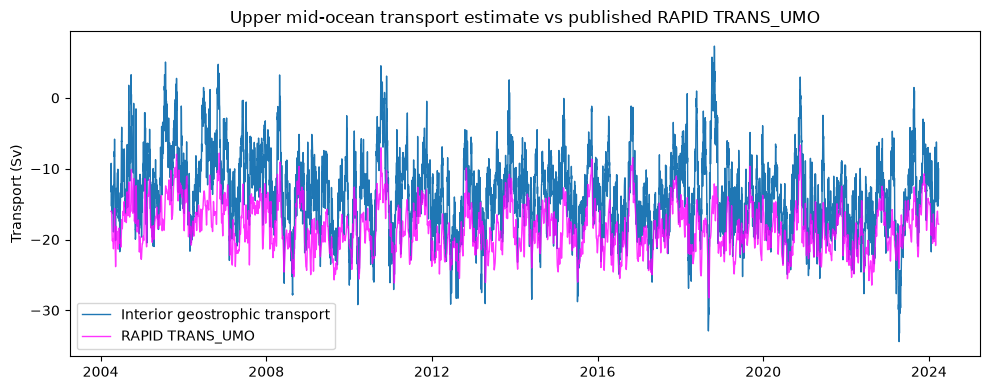

In [75]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(trans["TIME"].values, ours, label="Interior geostrophic transport", lw=1)
ax.plot(trans["TIME"].values, umo_on_ours, label="RAPID TRANS_UMO", lw=1, alpha=0.8, color= "magenta")
ax.set_ylabel("Transport (Sv)")
ax.set_title("Upper mid-ocean transport estimate vs published RAPID TRANS_UMO")
ax.legend()
plt.tight_layout()
plt.savefig("figs/part1_overlay.png", dpi=150)
plt.show()

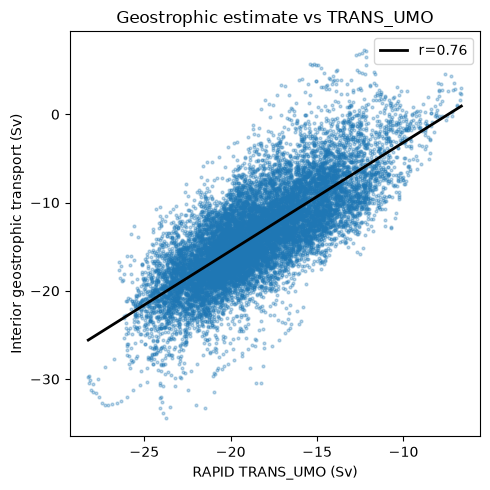

In [42]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(umo_g, ours_g, s=4, alpha=0.3)
xline = np.linspace(umo_g.min(), umo_g.max(), 2)
ax.plot(xline, slope * xline + intercept, color="k", lw=2,
         label=f"r={r:.2f}")
ax.set_xlabel("RAPID TRANS_UMO (Sv)")
ax.set_ylabel("Interior geostrophic transport (Sv)")
ax.set_title("Geostrophic estimate vs TRANS_UMO")
ax.legend()
plt.tight_layout()
plt.savefig("figs/part1_scatter.png", dpi=150)
plt.show()

PART2 Evaluating time series

2A — Single series: seasonal cycle and trend

In [43]:
from correlation_trends.seasonal import seasonal_climatology, remove_seasonal_cycle
from correlation_trends.correlation import autocorr, integral_timescale
from correlation_trends.trends import trend_with_significance
import xarray as xr
time_rapid, dt_rapid, rapid_series = load_amoc()
moc = rapid_series["MOC"]
trans_umo = rapid_series["TRANS_UMO"]

moc_da = xr.DataArray(moc, coords={"TIME": time_rapid}, dims="TIME", name="MOC")
trans_umo_da = xr.DataArray(trans_umo, coords={"TIME": time_rapid}, dims="TIME", name="TRANS_UMO")

#for moc
moc_climatology = seasonal_climatology(moc_da)
moc_deseasonalised = remove_seasonal_cycle(moc_da)
moc_autocorr = autocorr(moc_deseasonalised.values)
moc_tstar = integral_timescale(moc_deseasonalised.values, dt_rapid)
moc_trend = trend_with_significance(np.arange(len(moc_deseasonalised)), moc_deseasonalised.values, dt_rapid)

# for trans_umo
umo_climatology = seasonal_climatology(trans_umo_da)
umo_deseasonalised = remove_seasonal_cycle(trans_umo_da)
umo_autocorr = autocorr(umo_deseasonalised.values)
umo_tstar = integral_timescale(umo_deseasonalised.values, dt_rapid)
umo_trend = trend_with_significance(np.arange(len(umo_deseasonalised)), umo_deseasonalised.values, dt_rapid)

print("MOC:", moc_trend.slope, moc_trend.p_eff, moc_trend.n_eff)
print("TRANS_UMO:", umo_trend.slope, umo_trend.p_eff, umo_trend.n_eff)

Loading 1 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series

MOC: -0.00012700467624596182 0.051201270732238985 223.93294405424425
TRANS_UMO: -0.00014972720809278557 0.0028310605299900296 190.69280163609005


In [44]:
print("MOC t_naive vs t_eff:", moc_trend.t_naive, moc_trend.t_eff)
print("MOC p_naive vs p_eff:", moc_trend.p_naive, moc_trend.p_eff)
print("TRANS_UMO t_naive vs t_eff:", umo_trend.t_naive, umo_trend.t_eff)
print("TRANS_UMO p_naive vs p_eff:", umo_trend.p_naive, umo_trend.p_eff)

MOC t_naive vs t_eff: -15.82870553829395 -1.9603916345473966
MOC p_naive vs p_eff: 5.758667714542685e-56 0.051201270732238985
TRANS_UMO t_naive vs t_eff: -26.469672065756694 -3.0252004494792932
TRANS_UMO p_naive vs p_eff: 7.66491664361766e-151 0.0028310605299900296


Monthly Climatology

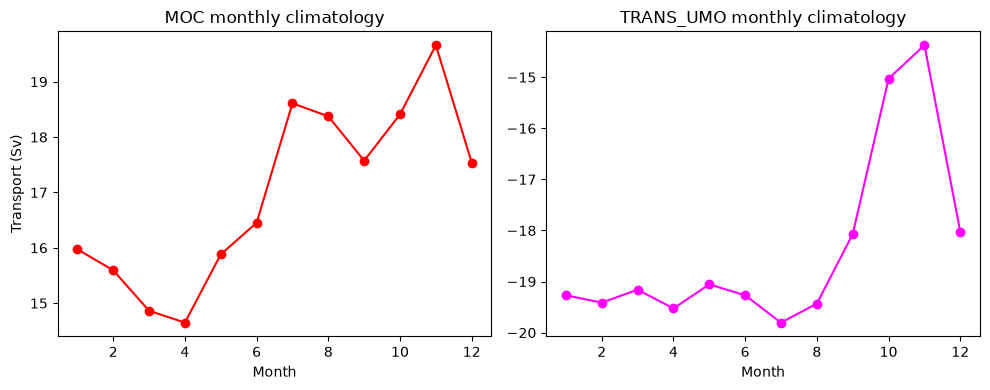

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(moc_climatology["month"], moc_climatology.values, marker="o", color="red")
axes[0].set_title("MOC monthly climatology")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Transport (Sv)")

axes[1].plot(umo_climatology["month"], umo_climatology.values, marker="o", color="magenta")
axes[1].set_title("TRANS_UMO monthly climatology")
axes[1].set_xlabel("Month")

plt.tight_layout()
plt.savefig("figs/part2a_climatology.png", dpi=150)
plt.show()

The de-seasonalised series (mean kept) over the raw

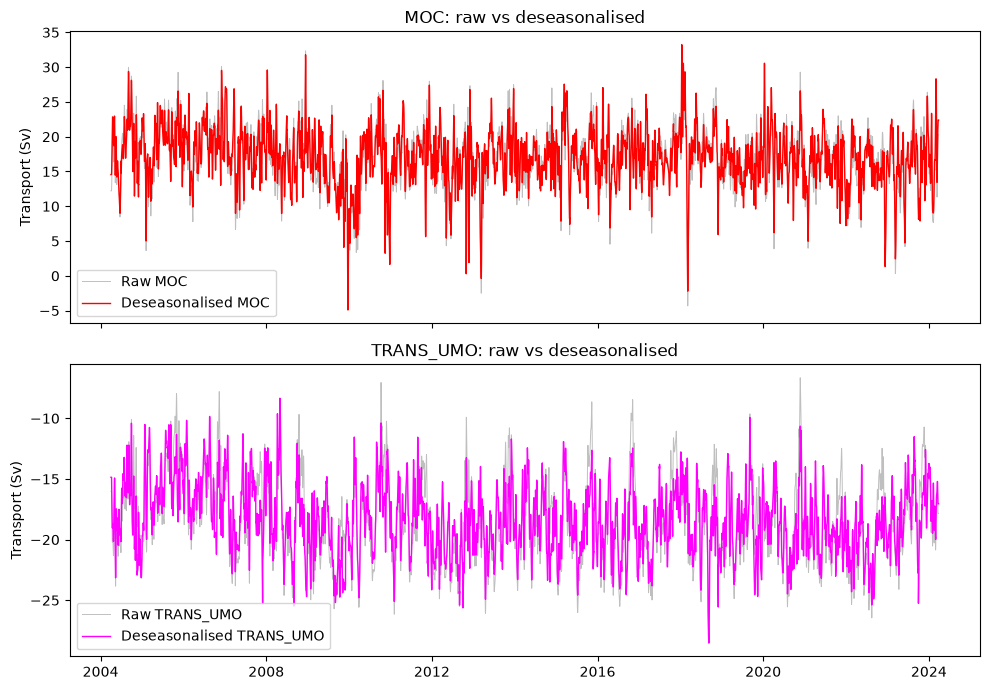

In [72]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(moc_da["TIME"], moc_da.values, lw=0.7, alpha=0.5, color="gray", label="Raw MOC")
axes[0].plot(moc_deseasonalised["TIME"], moc_deseasonalised.values, lw=1, color="red", label="Deseasonalised MOC")
axes[0].set_ylabel("Transport (Sv)")
axes[0].set_title("MOC: raw vs deseasonalised")
axes[0].legend()

axes[1].plot(trans_umo_da["TIME"], trans_umo_da.values, lw=0.7, alpha=0.5, color="gray", label="Raw TRANS_UMO")
axes[1].plot(umo_deseasonalised["TIME"], umo_deseasonalised.values, lw=1, color="magenta", label="Deseasonalised TRANS_UMO")
axes[1].set_ylabel("Transport (Sv)")
axes[1].set_title("TRANS_UMO: raw vs deseasonalised")
axes[1].legend()

plt.tight_layout()
plt.savefig("figs/part2a_deseasonalised.png", dpi=150)
plt.show()

Autocorrelation with the decorrelation timescale marked

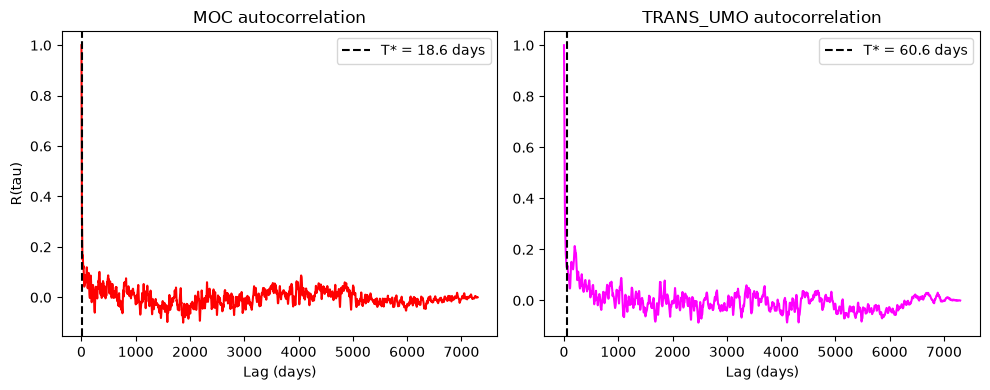

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

lags_days_moc = np.arange(len(moc_autocorr)) * dt_rapid
axes[0].plot(lags_days_moc, moc_autocorr,color = "red")
axes[0].axvline(moc_tstar, color="k", linestyle="--", label=f"T* = {moc_tstar:.1f} days")
axes[0].set_title("MOC autocorrelation")
axes[0].set_xlabel("Lag (days)")
axes[0].set_ylabel("R(tau)")
axes[0].legend()

lags_days_umo = np.arange(len(umo_autocorr)) * dt_rapid
axes[1].plot(lags_days_umo, umo_autocorr, color="magenta")
axes[1].axvline(umo_tstar, color="k", linestyle="--", label=f"T* = {umo_tstar:.1f} days")
axes[1].set_title("TRANS_UMO autocorrelation")
axes[1].set_xlabel("Lag (days)")
axes[1].legend()

plt.tight_layout()
plt.savefig("figs/part2a_autocorrelation.png", dpi=150)
plt.show()

The trend fit with its honest confidence band

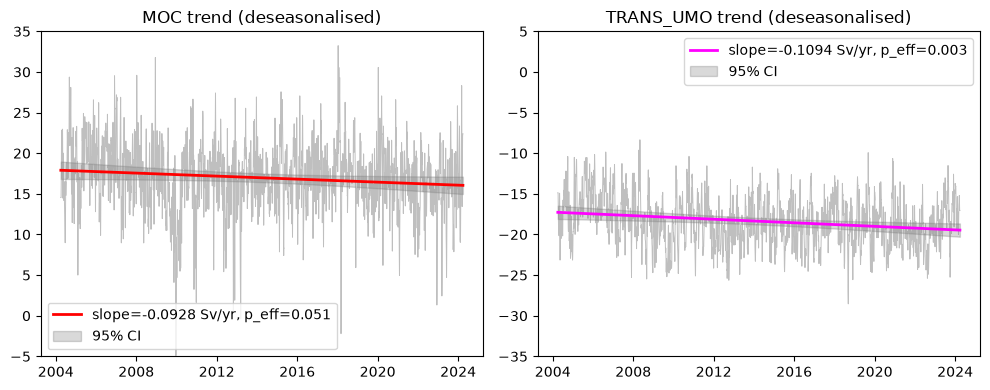

In [68]:
from matplotlib.ticker import MultipleLocator

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

t_moc = np.arange(len(moc_deseasonalised))
fit_moc = moc_trend.slope * t_moc + moc_trend.intercept
Sxx_moc = np.sum((t_moc - t_moc.mean())**2)
band_moc = 1.96 * moc_trend.se_eff * np.sqrt(Sxx_moc / len(t_moc) + (t_moc - t_moc.mean())**2)

Sxx_umo = np.sum((t_umo - t_umo.mean())**2)
band_umo = 1.96 * umo_trend.se_eff * np.sqrt(Sxx_umo / len(t_umo) + (t_umo - t_umo.mean())**2)

axes[0].set_ylim(-5, 35)
axes[0].plot(moc_deseasonalised["TIME"], moc_deseasonalised.values, lw=0.7, alpha=0.5, color="gray")
axes[0].plot(moc_deseasonalised["TIME"], fit_moc, color="r", lw=2,
            label=f"slope={moc_trend.slope * 365.25 / dt_rapid:.4f} Sv/yr, p_eff={moc_trend.p_eff:.3f}")
axes[0].fill_between(moc_deseasonalised["TIME"], fit_moc - band_moc, fit_moc + band_moc, color="k", alpha=0.15,label="95% CI")
axes[0].set_title("MOC trend (deseasonalised)")
axes[0].legend()

t_umo = np.arange(len(umo_deseasonalised))
fit_umo = umo_trend.slope * t_umo + umo_trend.intercept

axes[1].set_ylim(-35, 5)
axes[1].plot(umo_deseasonalised["TIME"], umo_deseasonalised.values, lw=0.7, alpha=0.5, color="gray")
axes[1].plot(umo_deseasonalised["TIME"], fit_umo, color="magenta", lw=2,
            label=f"slope={umo_trend.slope * 365.25 / dt_rapid:.4f} Sv/yr, p_eff={umo_trend.p_eff:.3f}")
axes[1].fill_between(umo_deseasonalised["TIME"], fit_umo - band_umo, fit_umo + band_umo, color="k", alpha=0.15,label="95% CI")
axes[1].set_title("TRANS_UMO trend (deseasonalised)")
axes[1].legend()

for ax in axes:
    ax.yaxis.set_major_locator(MultipleLocator(5))

plt.tight_layout()
plt.savefig("figs/part2a_trend.png", dpi=150)
plt.show()


# uniti ekle slope tek kaldı per year olmalı check p_eff

2B — A pair of series: TRANS_EKMAN vs MOC

In [49]:
from correlation_trends.correlation import cross_correlation

trans_ekman = rapid_series["TRANS_EKMAN"]
trans_ekman_da = xr.DataArray(trans_ekman, coords={"TIME": time_rapid}, dims="TIME", name="TRANS_EKMAN")

ekman_deseasonalised = remove_seasonal_cycle(trans_ekman_da)
# moc_deseasonalised have done it before

lags, cross_corr = cross_correlation(ekman_deseasonalised.values, moc_deseasonalised.values)

peak_idx = np.argmax(np.abs(cross_corr))
peak_lag_samples = lags[peak_idx]
peak_lag_days = peak_lag_samples * dt_rapid
peak_r = cross_corr[peak_idx]

print(f"Peak lag: {peak_lag_samples} samples = {peak_lag_days:.1f} days")
print(f"Peak correlation: {peak_r:.3f}")


Peak lag: -1 samples = -0.5 days
Peak correlation: 0.718


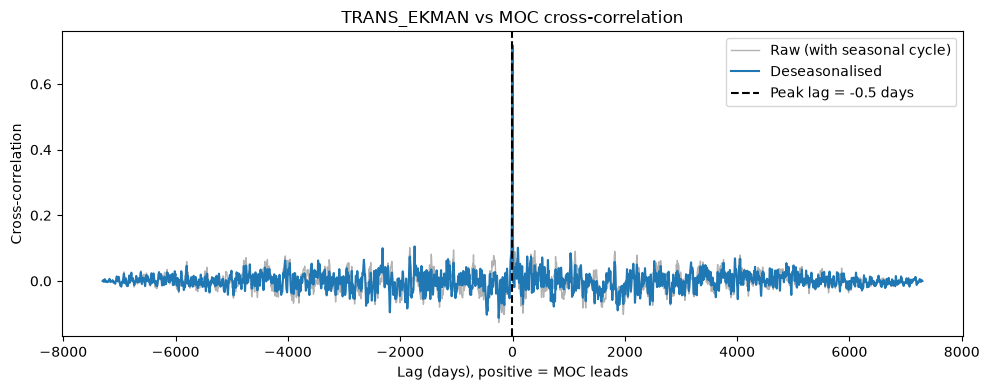

In [50]:
lags_raw, cross_corr_raw = cross_correlation(trans_ekman_da.values, moc_da.values)

fig, ax = plt.subplots(figsize=(10, 4))

lags_days = lags * dt_rapid
lags_raw_days = lags_raw * dt_rapid

ax.plot(lags_raw_days, cross_corr_raw, color="gray", lw=1, alpha=0.6, label="Raw (with seasonal cycle)")
ax.plot(lags_days, cross_corr, color="tab:blue", lw=1.5, label="Deseasonalised")
ax.axvline(peak_lag_days, color="k", linestyle="--", label=f"Peak lag = {peak_lag_days:.1f} days")
ax.set_xlabel("Lag (days), positive = MOC leads")
ax.set_ylabel("Cross-correlation")
ax.set_title("TRANS_EKMAN vs MOC cross-correlation")
ax.legend()

plt.tight_layout()
plt.savefig("figs/part2b_cross_correlation.png", dpi=150)
plt.show()



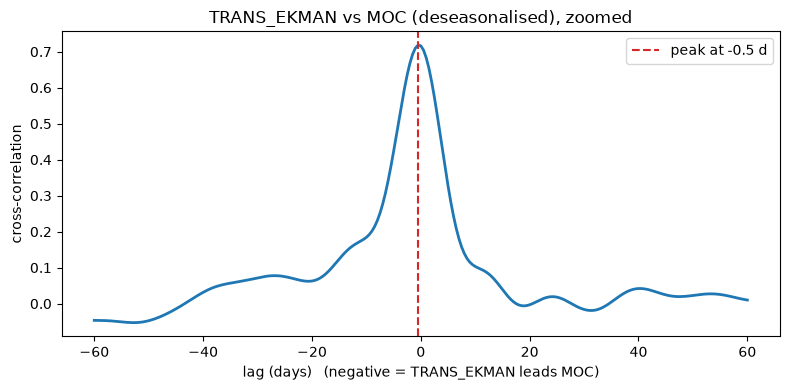

In [51]:
fig, ax = plt.subplots(figsize=(8, 4))

zoom = (lags_days >= -60) & (lags_days <= 60)
ax.plot(lags_days[zoom], cross_corr[zoom], lw=2, color="tab:blue")
ax.axvline(peak_lag_days, color="tab:red", linestyle="--",
           label=f"peak at {peak_lag_days:.1f} d")
ax.set_xlabel("lag (days)   (negative = TRANS_EKMAN leads MOC)")
ax.set_ylabel("cross-correlation")
ax.set_title("TRANS_EKMAN vs MOC (deseasonalised), zoomed")
ax.legend()

plt.tight_layout()
plt.savefig("figs/part2b_cross_correlation_zoom.png", dpi=150)
plt.show()

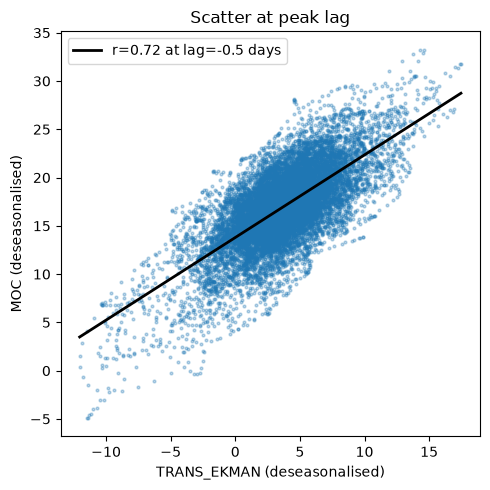

In [52]:
# peak_lag_samples kadar kaydırılmış hizalama
if peak_lag_samples >= 0:
    x_shifted = ekman_deseasonalised.values[:len(ekman_deseasonalised) - peak_lag_samples]
    y_shifted = moc_deseasonalised.values[peak_lag_samples:]
else:
    k = -peak_lag_samples
    x_shifted = ekman_deseasonalised.values[k:]
    y_shifted = moc_deseasonalised.values[:len(moc_deseasonalised) - k]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x_shifted, y_shifted, s=4, alpha=0.3)
slope_peak, intercept_peak = np.polyfit(x_shifted, y_shifted, 1)
x_line = np.linspace(x_shifted.min(), x_shifted.max(), 2)
ax.plot(x_line, slope_peak * x_line + intercept_peak, color="k", lw=2,
        label=f"r={peak_r:.2f} at lag={peak_lag_days:.1f} days")
ax.set_xlabel("TRANS_EKMAN (deseasonalised)")
ax.set_ylabel("MOC (deseasonalised)")
ax.set_title("Scatter at peak lag")
ax.legend()

plt.tight_layout()
plt.savefig("figs/part2b_scatter_peak_lag.png", dpi=150)
plt.show()

In [53]:
tstar_ekman = integral_timescale(ekman_deseasonalised.values, dt_rapid)
tstar_moc = integral_timescale(moc_deseasonalised.values, dt_rapid)

# konservatif yaklaşım: ikisinden büyük olanı kullan
tstar_pair = max(tstar_ekman, tstar_moc)

n_samples = len(ekman_deseasonalised)
record_days = n_samples * dt_rapid
n_eff_pair = record_days / (2 * tstar_pair)

print(f"T* (Ekman): {tstar_ekman:.1f} days")
print(f"T* (MOC): {tstar_moc:.1f} days")
print(f"Effective independent samples (N_eff): {n_eff_pair:.1f}")
print(f"Raw N: {n_samples}")

T* (Ekman): 6.9 days
T* (MOC): 18.6 days
Effective independent samples (N_eff): 195.8
Raw N: 14599


In [54]:
from scipy import stats

t_stat = peak_r * np.sqrt((n_eff_pair - 2) / (1 - peak_r**2))
p_value = 2 * stats.t.sf(np.abs(t_stat), df=n_eff_pair - 2)

print(f"r = {peak_r:.3f}")
print(f"t-statistic (with N_eff): {t_stat:.2f}")
print(f"p-value (with N_eff): {p_value:.4f}")
print("Significant at 95%:", "YES" if p_value < 0.05 else "NO")

r = 0.718
t-statistic (with N_eff): 14.36
p-value (with N_eff): 0.0000
Significant at 95%: YES


In [55]:
#some checks to compare the numbers from the class
umo_deseasonalised_check = remove_seasonal_cycle(trans_umo_da)
lags_umo_moc, cross_corr_umo_moc = cross_correlation(umo_deseasonalised_check.values, moc_deseasonalised.values)
peak_idx_umo_moc = np.argmax(np.abs(cross_corr_umo_moc))
print("TRANS_UMO vs MOC peak r:", cross_corr_umo_moc[peak_idx_umo_moc])
print("at lag:", lags_umo_moc[peak_idx_umo_moc] * dt_rapid, "days")

TRANS_UMO vs MOC peak r: 0.2461405853950115
at lag: 6.5 days


PART3
The depth sensitivity of your Part 1 transport (integrate to 700 / 1000 / 1100 m and
compare the mean and correlation)

In [56]:
depths = [700.0, 1000.0, 1100.0]
transports_by_depth = {}

for z in depths:
    transports_by_depth[z] = interior_geostrophic_transport(ts, z_max=z)

In [57]:
time_ours_int = transports_by_depth[1100.0]["TIME"].values.astype("datetime64[ns]").astype("int64")
time_rapid_int = time_rapid.astype("datetime64[ns]").astype("int64")
trans_umo_on_ours = np.interp(time_ours_int, time_rapid_int, trans_umo)

print(f"{'z_max (m)':>10} {'mean (Sv)':>12} {'std (Sv)':>12} {'r vs UMO':>10}")
for z in depths:
    vals = transports_by_depth[z].values
    valid = np.isfinite(vals) & np.isfinite(trans_umo_on_ours)
    r = np.corrcoef(vals[valid], trans_umo_on_ours[valid])[0, 1]
    print(f"{z:>10.0f} {np.nanmean(vals):>12.2f} {np.nanstd(vals):>12.2f} {r:>10.3f}")

 z_max (m)    mean (Sv)     std (Sv)   r vs UMO
       700       -16.38         4.40      0.787
      1000       -14.11         5.29      0.772
      1100       -13.46         5.50      0.762
